# Analysis of increasing the grid for solving the model

## Dependencies, Packages & Roots

### Magics

In [61]:
%reload_ext autoreload
%autoreload 2

### Project Paths

In [62]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

## Load Data 

In [63]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_level_file = pp.MOMENTS_DIR / "moments_udd1.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd2.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd3.txt"

MORTALITY = pp.DATA_DIR / "mortality.xlsx"

beta0, beta1, beta2 = np.loadtxt(pp.FIRST_STAGE_RESULTS_DIR / "wage_params_udd1_ols.txt")

In [64]:
PARAM_FILE = pp.STRUCTURAL_RESULTS_DIR / "optimized_own_params_udd1.txt"
params = load_params_txt(PARAM_FILE)
# params

In [65]:
# Read CSV
df_edu = pd.read_csv(education_level_file)
# read mortality and discard seoncd and third column
df_mort = pd.read_excel(MORTALITY, sheet_name="DOD", usecols=[0, 3])

# 2) standardize colomn name and remove _FREQ_ column
# Iterate over DataFrames (if there are multiple DataFrames to process)
for data_frame in [df_edu]:
    # Rename ALDER → age
    if "ALDER" in data_frame.columns:
        data_frame.rename(columns={"ALDER": "age"}, inplace=True)
    # Remove _FREQ_-column if it exists
    # if "_FREQ_" in data_frame.columns:
    #     data_frame.drop(columns=["_FREQ_"], inplace=True)
# drop var_wage, skew_wage and pens
df_edu.drop(columns=["var_wage", "skew_wage", "pens"], inplace=True)
# df_edu

# ====================================================================================================================

# Solving and simulating the model

## Options for model - Choices and states

In [113]:
n_periods = 55
labour_choices = np.arange(5) # 5 choices
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR/ "mortality_params.txt")

model_config = {
    "n_periods": n_periods,
    "choices": labour_choices, # 5 choices
    "n_quad_points": 9,
    "continuous_states": {
        "assets_end_of_period": np.linspace(0, 50, 20),
        "experience": jnp.linspace(0, 1, 5).astype(float) # 1 experince grid point, if experience can only go up by a year - more points if it is a fraction based on hours worked
        },
    "stochastic_states": {
        "survival": [0, 1],
    }
    }

model_specs = {
    "n_periods": n_periods,
    "labour_choices": labour_choices, # 5 choices
    "hours": jnp.array([0,250,750,1300,1900]), #list 
    "max_hours": 1500,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount":0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": alpha1, # independently estimated parameter for survival probability
    "alpha2": alpha2,  # independently estimated parameter for survival probability
    "max_init_experience": 5,
    "max_ret_period": 45, # Age 75
    "min_ret_period": 30, # Age 60
}
stochastic_states_transitions = {
    "survival": prob_survival
}

### Setup the model

In [114]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

State specific choice set not provided. Assume all choices are available in every state.
Update function for state space not given. Assume states only change with an increase of the period and lagged choice.
Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



### Initial values for simulating. 

In [115]:
# Select number of individuals for simulation
#Debug level
# n_individuals = 10

# Optimal level
n_individuals = 100000

seed = 132
key = jax.random.PRNGKey(0)
n = n_individuals       

# hours mapping for simulation
hours_map = {0: 0, 1: 250, 2: 750, 3: 1300, 4: 1900}

#age for simulation
start_age = model_specs["start_age"] 

# distribution of initial choices
labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
probs  = jnp.array([0.259155, 0.118310, 0.108099, 0.108451, 0.405986])  # sums to 1.0

lagged_choice = jax.random.choice(
    key,
    a       = labels,
    shape   = (n,),
    p       = probs,
    replace = True
)

# set initial states for each individual
states_initial = {
    "period": jnp.zeros(n_individuals, dtype=jnp.int32),      # Every individual starts at period 0 (age 30)
    "lagged_choice": lagged_choice,  # Every individual starts with choice 3 (work fulltime)
    "experience": jnp.full(n_individuals, 1).astype(float),  # Every individual starts with 5 years of experience
    "survival": jnp.ones(n_individuals, dtype=jnp.int32), # Every individual starts with 1 (alive)
    "assets_begin_of_period": jnp.full(n_individuals, 0.505047) # Every individual starts with 59k wealth - to be adjusted based on the actual moments
}

## Plots

In [116]:
labels = {
    "avg_wealth": "Average Wealth",
    "hours_0": "Unemployed",
    "hours_1": "Below 10 hours",
    "hours_2": "10-20 hours",
    "hours_3": "20-30 hours",
    "hours_4": "Above 30 hours",
    "avg_hours": "Average Hours",
    "prob_work": "Employment Rate",
    "avg_wage": "Average Wage",
    "avg_experience": "Average Experience",
    "work_work": "Work to Work Transition Rate",
    "nowork_nowork": "No Work to No Work Transition Rate",
}

scales = {
    "avg_wealth": 100_000,
    "avg_wage": 100_000,
}

### Load params, solve model and simulate juts once

In [117]:
params = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / "optimized_params_udd1.txt")
# If you want to see Frederiks original parameters, load optimized_params_udd1.txt instead
params["gamma"] = jnp.asarray(params["gamma"])

model_solved = model.solve(params)
sim = model_solved.simulate(
    states_initial=states_initial,
    seed=seed,
)

Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\model_specs_assets_notfine\prob_work_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\model_specs_assets_notfine\hours_0_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\model_specs_assets_notfine\hours_1_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\model_specs_assets_notfine\hours_2_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\model_specs_assets_notfine\hours_3_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\model_specs_assets_notfine\hours_4_over_age.png
Saved C:\Users\Nashw\Studi

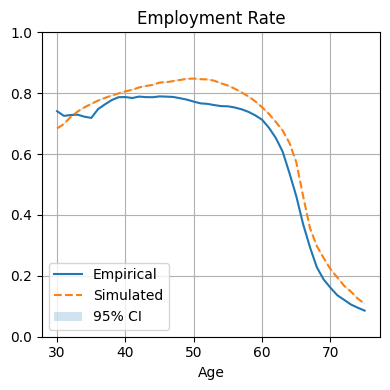

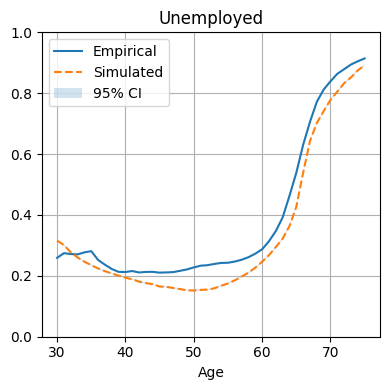

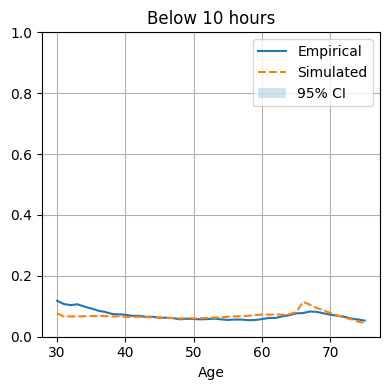

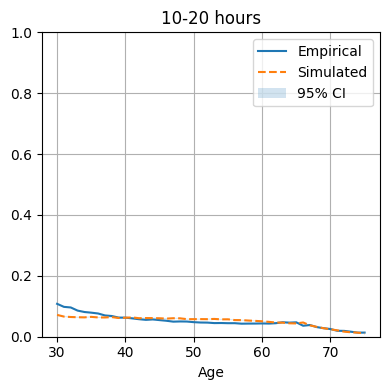

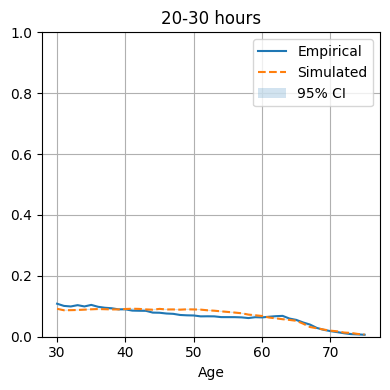

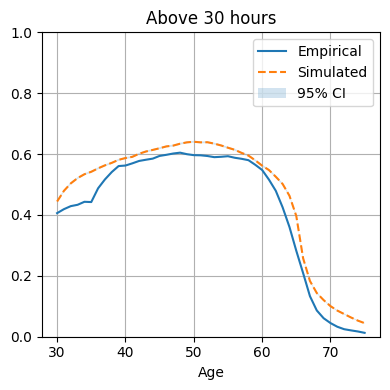

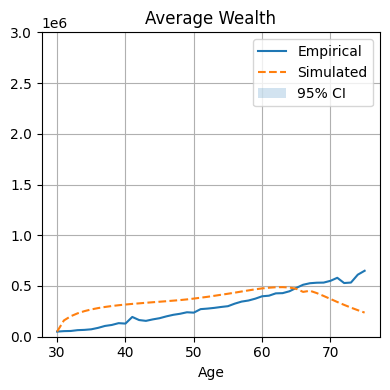

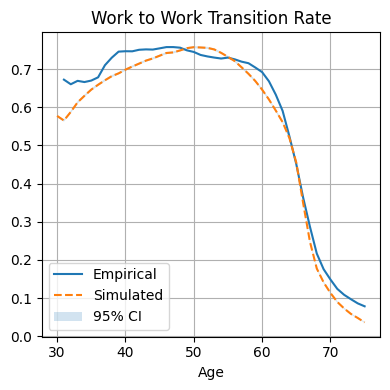

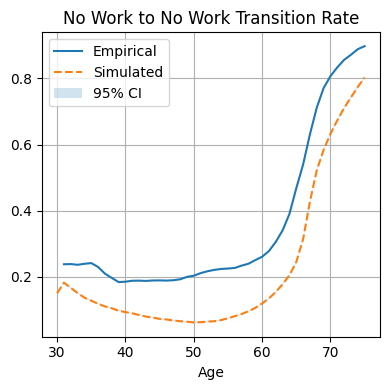

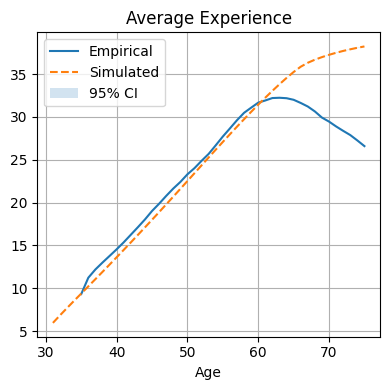

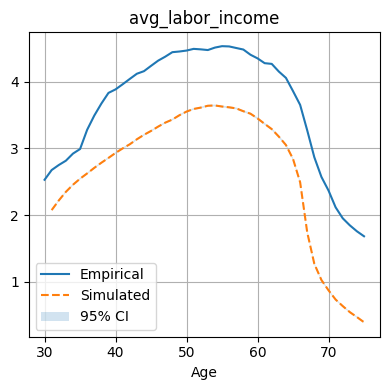

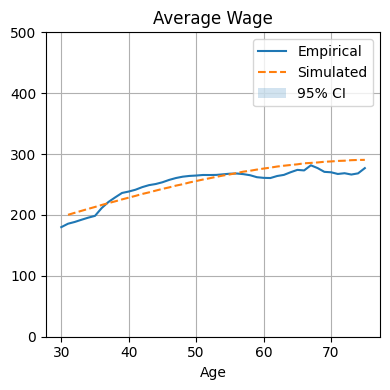

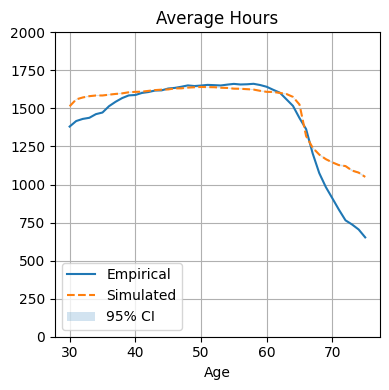

In [118]:
edu = df_edu.copy().loc[df_edu.age <= 75]       # empirical
moments_sim = compute_simulation_moments_with_ci(sim, start_age, hours_map)  # Call the function
# Ensure moments_sim.age is a pandas Series before filtering
moments_sim = moments_sim.loc[pd.Series(moments_sim.age) <= 75]  # Filter simulated + CIs
# scale avg_wealth by 100_000

# print plots
plot_empirical_vs_simulated_with_ci(
    edu = edu,
    moments_sim = moments_sim,
    out_subfolder="model_specs_assets_notfine",
    var_labels=labels,
    var_scales=scales,
    ylims={"avg_wealth": (0, 3_000_000), "avg_hours": (0, 2_000), "prob_work": (0, 1), "hours_0": (0, 1), "hours_1": (0, 1), "hours_2": (0, 1), "hours_3": (0, 1), "hours_4": (0, 1), "avg_wage": (0,500) },
)

### Inspecting what happens with solution after 200 gridpoints for assets

In [94]:
import numpy as np
import pandas as pd


# ============================================================
# Helper: safely extract solution arrays from model_solved
# ============================================================

def get_solution_array(model_solved, name):
    """
    Try to extract solution arrays such as value, policy, or endog_grid
    from a dcegm solved model object.
    """

    # Case 1: model_solved has attributes directly
    if hasattr(model_solved, name):
        return np.asarray(getattr(model_solved, name))

    # Case 2: model_solved has sol_dict
    if hasattr(model_solved, "sol_dict"):
        sol_dict = model_solved.sol_dict

        if isinstance(sol_dict, dict) and name in sol_dict:
            return np.asarray(sol_dict[name])

    # Case 3: model_solved itself is a dict
    if isinstance(model_solved, dict) and name in model_solved:
        return np.asarray(model_solved[name])

    raise AttributeError(f"Could not find '{name}' in model_solved.")


# ============================================================
# Helper: summarize numerical array
# ============================================================

def summarize_array(arr, name):
    """
    Print basic numerical diagnostics for an array.
    """
    arr = np.asarray(arr)

    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", arr.shape)
    print("dtype:", arr.dtype)
    print("nan:", np.isnan(arr).any())
    print("inf:", np.isinf(arr).any())
    print("min:", np.nanmin(arr))
    print("p01:", np.nanpercentile(arr, 1))
    print("p50:", np.nanpercentile(arr, 50))
    print("p99:", np.nanpercentile(arr, 99))
    print("max:", np.nanmax(arr))


# ============================================================
# 1. Inspect model_solved object
# ============================================================

print("model_solved type:")
print(type(model_solved))

print("\nAvailable attributes containing likely solution names:")
for attr in dir(model_solved):
    if any(key in attr.lower() for key in ["value", "policy", "grid", "sol"]):
        print("  ", attr)


# ============================================================
# 2. Inspect solution arrays
# ============================================================

for name in ["value", "policy", "endog_grid"]:
    try:
        arr = get_solution_array(model_solved, name)
        summarize_array(arr, name)
    except Exception as e:
        print(f"\nCould not inspect {name}: {e}")


# ============================================================
# 3. Inspect model batching information
# ============================================================

print("\nModel batching information")
print("--------------------------")

try:
    n_assets = len(model_config["continuous_states"]["assets_end_of_period"])
    print("n_assets:", n_assets)
except Exception as e:
    print("Could not read n_assets:", e)

print("model type:", type(model))

if hasattr(model, "batch_info"):
    batch_info = model.batch_info

    print("batch_info type:", type(batch_info))

    if isinstance(batch_info, dict):
        print("batch_info keys:")
        for key in batch_info.keys():
            print("  ", key)

        print("\nn_segments:", batch_info.get("n_segments", "not found"))

        for key, val in batch_info.items():
            if "segment" in str(key):
                print(f"\n{key}")
                print("type:", type(val))

                if isinstance(val, dict):
                    print("keys:")
                    for subkey in val.keys():
                        print("  ", subkey)

                    if "batches_cover_all" in val:
                        print("batches_cover_all:", val["batches_cover_all"])

                    for subkey, subval in val.items():
                        if hasattr(subval, "shape"):
                            print(f"{subkey}: shape={subval.shape}, dtype={getattr(subval, 'dtype', None)}")
                else:
                    print(val)
    else:
        print(batch_info)
else:
    print("model has no attribute 'batch_info'")


# ============================================================
# 4. Inspect simulated choices and assets
# ============================================================

print("\nSimulation diagnostics")
print("----------------------")

df_sim = sim.reset_index()

print("\nColumns:")
print(df_sim.columns.tolist())

if "choice" in df_sim.columns:
    print("\nChoice distribution:")
    print(df_sim["choice"].value_counts(normalize=True).sort_index())

    if "period" in df_sim.columns:
        choice_by_period = (
            df_sim.groupby("period")["choice"]
            .value_counts(normalize=True)
            .rename("share")
            .reset_index()
            .pivot(index="period", columns="choice", values="share")
        )

        print("\nChoice distribution by period, first 20 periods:")
        display(choice_by_period.head(20))

        print("\nChoice distribution by period, last 20 periods:")
        display(choice_by_period.tail(20))

if "assets_begin_of_period" in df_sim.columns:
    print("\nAssets beginning of period:")
    print(
        df_sim["assets_begin_of_period"]
        .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    )

    print("\nShare close to asset upper bound:")
    print("Share assets > 45:", (df_sim["assets_begin_of_period"] > 45).mean())
    print("Share assets > 49:", (df_sim["assets_begin_of_period"] > 49).mean())
    print("Share assets > 75:", (df_sim["assets_begin_of_period"] > 75).mean())
    print("Share assets > 95:", (df_sim["assets_begin_of_period"] > 95).mean())

if "period" in df_sim.columns and "assets_begin_of_period" in df_sim.columns:
    assets_by_period = (
        df_sim.groupby("period")["assets_begin_of_period"]
        .describe(percentiles=[0.5, 0.9, 0.99])
    )

    print("\nAssets by period, first 10 periods:")
    display(assets_by_period.head(10))

    print("\nAssets by period, last 10 periods:")
    display(assets_by_period.tail(10))

model_solved type:
<class 'dcegm.interfaces.sol_interface.model_solved'>

Available attributes containing likely solution names:
   choice_values_for_states
   endog_grid
   get_solution_for_discrete_state_choice
   policy
   policy_and_value_for_states_and_choices
   policy_for_states_and_choices
   value
   value_for_states_and_choices

value
-----
shape: (1400, 5, 241)
dtype: float64
nan: True
inf: True
min: -5235277.523219678
p01: -3.6914040956123104
p50: 126.70563005755905
p99: 3137857.880319456
max: inf

policy
------
shape: (1400, 5, 241)
dtype: float64
nan: True
inf: True
min: -901.2144507387519
p01: 0.0
p50: 3.0391558677620387
p99: 1066339733.725171
max: inf

endog_grid
----------
shape: (1400, 5, 241)
dtype: float64
nan: True
inf: True
min: -532.778503881139
p01: 0.648917482889307
p50: 22.516720357326744
p99: 1066339773.725171
max: inf

Model batching information
--------------------------
n_assets: 201
model type: <class 'dcegm.interfaces.model_class.setup_model'>
batch_info

choice,0,1,2,3,4
period,,,,,
0,NaN,NaN,NaN,NaN,1.00000
1,NaN,NaN,NaN,NaN,1.00000
2,NaN,0.01474,0.00002,0.00002,0.98522
3,0.10993,NaN,0.29565,0.03065,0.56377
4,0.00021,0.00002,0.00007,0.98073,0.01897
5,0.00119,0.00115,0.00235,0.04636,0.94895
6,0.72226,0.00599,0.15158,0.08958,0.03059
7,0.00034,0.00017,0.05385,0.49034,0.45530
8,0.00007,0.00147,0.08063,0.04775,0.87008



Choice distribution by period, last 20 periods:


choice,0,1,2,3,4
period,,,,,
35,0.12201,0.04931,0.39827,0.00315,0.42726
36,0.03691,0.00874,0.05005,0.05288,0.85142
37,0.06954,0.01455,0.05394,0.02885,0.83312
38,0.37372,0.06589,0.12521,0.30363,0.13155
39,0.55573,0.06986,0.11919,0.10886,0.14636
40,0.72194,0.07793,0.03424,0.00355,0.16234
41,0.70160,0.08682,0.02856,0.00361,0.17941
42,0.72767,0.06634,0.00428,0.00420,0.19751
43,0.74052,0.00472,0.00419,0.00435,0.24622



Assets beginning of period:
count    4.937429e+06
mean     5.447126e+10
std      1.275902e+14
min     -4.031433e+16
1%      -4.408969e+01
5%       5.050470e-01
50%      8.332743e+00
90%      3.016850e+01
95%      3.605312e+01
99%      4.390839e+01
max      3.985496e+16
Name: assets_begin_of_period, dtype: float64

Share close to asset upper bound:
Share assets > 45: 0.007972363636363637
Share assets > 49: 0.0061045454545454545
Share assets > 75: 0.0024569090909090908
Share assets > 95: 0.002060909090909091

Assets by period, first 10 periods:


,count,mean,std,min,50%,90%,99%,max
period,,,,,,,,
0,100000.0,0.505047,2.220457e-16,5.050470e-01,0.505047,0.505047,0.505047,0.505047
1,100000.0,2.541785,3.492032e-01,1.471449e+00,2.515972,3.002716,3.462083,4.416317
2,100000.0,4.395565,3.565923e-01,1.780346e+00,4.368310,4.862737,5.351180,6.212399
3,100000.0,5.046226,2.084016e+00,0.000000e+00,4.383341,8.072597,8.819515,10.266455
4,99994.0,6.732517,3.338237e+00,-2.220446e-16,5.995557,9.248103,9.848717,371.126984
5,99989.0,12.663906,3.864660e+00,-4.440892e-16,13.960354,15.999666,17.813080,206.336200
6,99973.0,15.979228,5.189226e+00,-1.776357e-15,17.887506,21.156251,23.115093,114.737134
7,99946.0,17.867637,6.682160e+00,-1.776357e-15,19.385879,26.039636,28.941091,30.962079
8,99912.0,16.772050,1.962064e+01,-3.552714e-15,15.832099,19.582542,53.053975,473.858930



Assets by period, last 10 periods:


,count,mean,std,min,50%,90%,99%,max
period,,,,,,,,
45,76734.0,3.811969e+00,2.963543e+00,-1.776357e-15,3.169570,5.246132,17.631164,26.262345
46,74499.0,3.225905e+00,2.427264e+00,-3.552714e-15,2.708044,4.527775,14.367610,21.594152
47,72076.0,2.729474e+00,1.941197e+00,-1.776357e-15,2.313626,3.954152,11.479270,17.453761
48,69450.0,2.305016e+00,1.516617e+00,-1.776357e-15,1.994043,3.444477,8.968910,13.807101
49,66722.0,1.919478e+00,1.152054e+00,-8.881784e-16,1.715812,2.845066,6.809237,10.775580
50,63712.0,1.574148e+00,8.555890e-01,-8.881784e-16,1.463929,2.245213,4.982995,8.362684
51,60503.0,1.129544e+00,1.321783e+01,-2.745511e+03,1.156104,2.070156,4.695651,8.730834
52,56928.0,-1.923208e+11,4.588695e+13,-1.094844e+16,1.068533,3.476809,4.557799,7.306168
53,51032.0,1.119388e+00,1.180822e+01,-9.622721e+02,1.068533,2.780625,4.112770,6.466505
